<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Streaming fraud — the score, from training to inference, and its drift

*Draft notebook, the narrative view of `src/scoring/policy.py` and `src/scoring/monitoring.py`. It follows one number, the fraud score, through its whole life: how it is **derived at training time**, how it is **applied unchanged at inference**, and how we **watch it drift** with a Shapley attribution. All code is for you to run and verify. Author to rework the prose.*

The thread of the notebook is a single idea: **the score is a training artifact**. The model produces a raw probability, but the thing the fraud desk reads, a 0 to 1000 score whose cut carries a known false-alarm rate, is defined once from the training data and then frozen. Inference does not re-derive it; it looks each new transaction up against that frozen reference. Drift is what happens when live traffic stops matching it.

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters and setup</h2>

Put the chapter's scoring package on the path first, so we can import the very functions the consumer ships with, `afd_score` and `decide` from `src/scoring/policy.py`.

In [1]:
import os
import sys

CHAPTER_DIR = os.path.abspath("..")
sys.path.insert(0, f"{CHAPTER_DIR}/src/scoring")

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from policy import (
    afd_score,
    decide,
    AFD_FPR,
    AFD_SCORE,
    BLOCK_CUT,
)  # the shipped score logic

APPROVE, INVESTIGATE, BLOCK = "#2CA25F", "#F0A030", "#E4408A"
pd.set_option("display.width", 100)

Load the frozen model and the chronological split. `train.csv` is what the model learned on; `test.csv` is the held-out future it never saw, standing in for live traffic.

In [3]:
with open(f"{CHAPTER_DIR}/artifacts/model_meta.json") as f:
    meta = json.load(f)
features, review_cut = meta["features"], meta["threshold"]
model = CatBoostClassifier()
model.load_model(f"{CHAPTER_DIR}/artifacts/model.cbm")

train = pd.read_csv(f"{CHAPTER_DIR}/data/split/train.csv", parse_dates=["event_time"])
test = pd.read_csv(f"{CHAPTER_DIR}/data/split/test.csv", parse_dates=["event_time"])
len(train), len(test), features

(40000,
 10000,
 ['amount_usd',
  'amount_over_user_avg',
  'seconds_since_last_txn',
  'is_first_merchant',
  'user_txn_count_24h',
  'merchant_fraud_rate',
  'merchant_age_days',
  'is_online',
  'is_night'])

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-random" style="color:#18ab4b"></i>&nbsp; The raw model output is a probability</h2>

The classifier returns a probability of fraud. It is accurate but awkward to act on: it piles up near zero, and a cut like *0.9* has no obvious operational meaning, is that one false alarm in ten, or one in a hundred? The next section fixes that by turning the probability into a calibrated score.

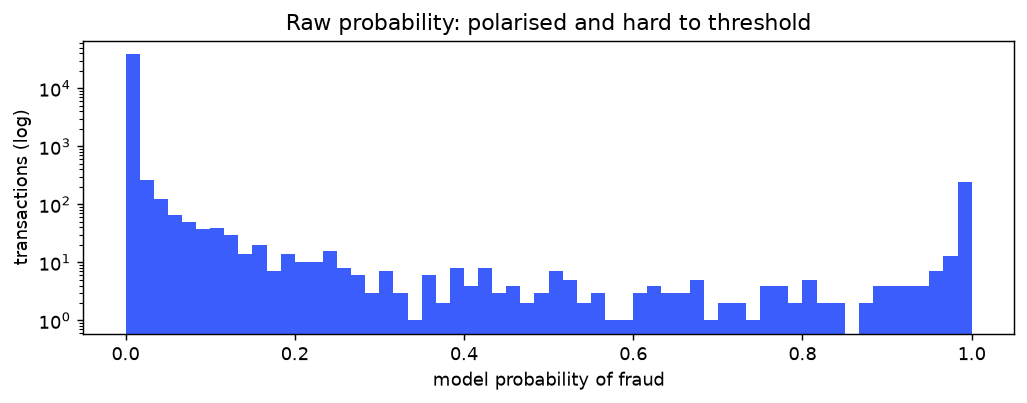

In [4]:
p_train = model.predict_proba(train[features])[:, 1]
p_test = model.predict_proba(test[features])[:, 1]

plt.figure(figsize=(8, 3.2), dpi=130)
plt.hist(p_train, bins=60, color="#3A5DFC")
plt.yscale("log")
plt.xlabel("model probability of fraud")
plt.ylabel("transactions (log)")
plt.title("Raw probability: polarised and hard to threshold")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-brain" style="color:#18ab4b"></i>&nbsp; Deriving the score at training time</h2>

Here is the derivation, and the point to hold onto: **it happens once, on training data**.

1. **Freeze a reference.** Take the probabilities the model assigns to the *legitimate* training transactions. This set, `legit`, is the yardstick every future score is measured against. It is frozen now and shipped with the model, exactly like the operating threshold in `model_meta.json`.
2. **Read a probability as a false-positive rate.** A transaction's FPR is the share of legitimate transactions it outranks. A transaction riskier than all but 2% of good ones has a 2% FPR.
3. **Calibrate the FPR to a 0 to 1000 score** through Amazon Fraud Detector's published (score, FPR) anchors, so a score means what it means in AFD: a score of 900 is a 2% false-alarm rate. This is what `afd_score` does.

In [5]:
# step 1: the reference is derived from training and then frozen
legit_reference = p_train[train["is_fraud"].values == 0]
print(
    f"reference set: {len(legit_reference):,} legitimate training probabilities (frozen, ships with the model)"
)

# AFD's published calibration anchors (from policy.py)
list(zip(AFD_SCORE, AFD_FPR))

reference set: 39,764 legitimate training probabilities (frozen, ships with the model)


[(np.int64(975), np.float64(0.005)),
 (np.int64(950), np.float64(0.01)),
 (np.int64(900), np.float64(0.02)),
 (np.int64(860), np.float64(0.03)),
 (np.int64(775), np.float64(0.05)),
 (np.int64(700), np.float64(0.07)),
 (np.int64(600), np.float64(0.1))]

The calibration curve is the score's definition. It passes through AFD's seven published points; between and beyond them `afd_score` interpolates and extends. Read it as: pick a false-alarm rate on the x-axis, the curve gives the score a cut there must use.

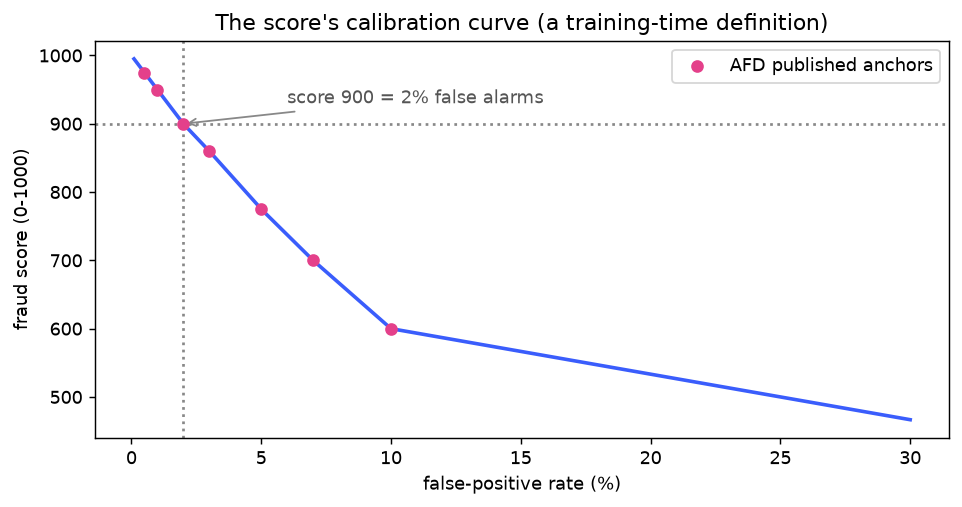

In [6]:
fpr_grid = np.linspace(0.001, 0.30, 400)


# invert afd_score's mapping for the curve: score as a function of FPR
def score_from_fpr(fpr):
    """Map a false-positive rate back to the calibrated score (the inverse of afd_score)."""
    s = np.empty_like(fpr)
    lo = fpr <= AFD_FPR[0]
    s[lo] = 1000 - (fpr[lo] / AFD_FPR[0]) * (1000 - AFD_SCORE[0])
    mid = (fpr > AFD_FPR[0]) & (fpr <= AFD_FPR[-1])
    s[mid] = np.interp(fpr[mid], AFD_FPR, AFD_SCORE)
    hi = fpr > AFD_FPR[-1]
    s[hi] = AFD_SCORE[-1] * (1 - fpr[hi]) / (1 - AFD_FPR[-1])
    return s


plt.figure(figsize=(7.5, 4), dpi=130)
plt.plot(fpr_grid * 100, score_from_fpr(fpr_grid), color="#3A5DFC", lw=2)
plt.scatter(
    AFD_FPR * 100, AFD_SCORE, color="#E4408A", zorder=5, label="AFD published anchors"
)
plt.axhline(900, color="#888", ls=":")
plt.axvline(2, color="#888", ls=":")
plt.annotate(
    "score 900 = 2% false alarms",
    (2, 900),
    (6, 930),
    color="#555",
    arrowprops=dict(arrowstyle="->", color="#888"),
)
plt.xlabel("false-positive rate (%)")
plt.ylabel("fraud score (0-1000)")
plt.title("The score's calibration curve (a training-time definition)")
plt.legend()
plt.tight_layout()
plt.show()

Sanity check on training data: scoring the training rows against their own reference should reproduce AFD's table, a score of 900 really is a 2% false-positive rate, 775 a 5% rate, and so on.

In [7]:
s_train = afd_score(p_train, legit_reference)
rows = []
for cut in (975, 950, 900, 860, 775, 700, 600):
    # FPR at a score cut = share of the reference outranked by the least-risky record above the cut
    mask = s_train >= cut
    fpr = (
        (legit_reference >= p_train[mask].min()).mean() if mask.any() else float("nan")
    )
    rows.append((cut, round(100 * fpr, 2)))
pd.DataFrame(rows, columns=["score cut", "false-positive rate (%)"])

,score cut,false-positive rate (%)
0,975,0.51
1,950,1.01
2,900,2.01
3,860,3.01
4,775,5.01
5,700,7.01
6,600,10.07


<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-bolt" style="color:#18ab4b"></i>&nbsp; Using the score at inference</h2>

Inference adds nothing to the derivation. A new transaction arrives, the model gives a probability, and `afd_score` looks it up against the **same frozen reference** to get a 0 to 1000 score. No retraining, no recomputation of the reference, the score logic is a pure function of (probability, frozen reference).

The `test` set is our stand-in for live traffic. We score it with the reference derived above, then apply the two-cut band policy (`decide`): block the clear fraud, send the gray band to review, approve the rest.

In [8]:
# the SAME frozen reference derived at training time is applied to unseen transactions
s_test = afd_score(p_test, legit_reference)

example = test[features].iloc[:5].copy()
example["probability"] = p_test[:5].round(4)
example["afd_score"] = s_test[:5]
example["outcome"] = [decide(p, review_cut) for p in p_test[:5]]
example[["amount_usd", "merchant_fraud_rate", "probability", "afd_score", "outcome"]]

,amount_usd,merchant_fraud_rate,probability,afd_score,outcome
0,7.21,0.0026,0.0,0,approve
1,61.76,0.0000,0.0,410,approve
2,21.00,0.0000,0.0,384,approve
3,17.14,0.0000,0.0,254,approve
4,36.83,0.0000,0.0,143,approve


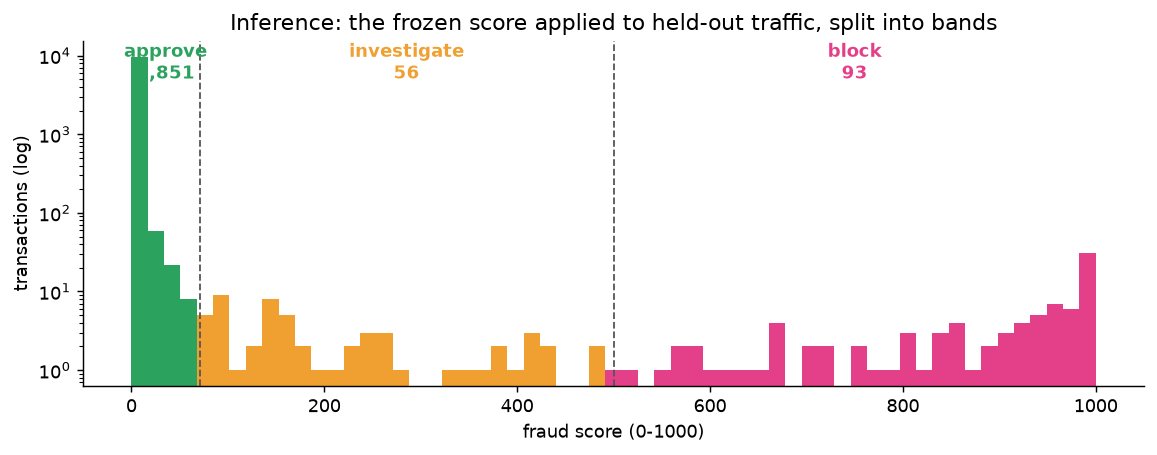

In [9]:
lo, hi = review_cut * 1000, BLOCK_CUT * 1000
disp = (p_test * 1000).clip(0, 1000)
counts = {
    o: int(sum(decide(p, review_cut) == o for p in p_test))
    for o in ("approve", "investigate", "block")
}
bins = np.linspace(0, 1000, 60)
plt.figure(figsize=(9, 3.6), dpi=130)
ax = plt.gca()
for a, b, c in [(0, lo, APPROVE), (lo, hi, INVESTIGATE), (hi, 1000, BLOCK)]:
    plt.hist(disp[(disp >= a) & (disp < b)], bins=bins, color=c)
for x in (lo, hi):
    plt.axvline(x, color="#555", ls="--", lw=1)
y = plt.ylim()[1] * 0.5
for x, lab, c in [
    (lo / 2, f"approve\n{counts['approve']:,}", APPROVE),
    ((lo + hi) / 2, f"investigate\n{counts['investigate']:,}", INVESTIGATE),
    ((hi + 1000) / 2, f"block\n{counts['block']:,}", BLOCK),
]:
    plt.text(x, y, lab, ha="center", color=c, weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.yscale("log")
plt.xlabel("fraud score (0-1000)")
plt.ylabel("transactions (log)")
plt.title("Inference: the frozen score applied to held-out traffic, split into bands")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-line" style="color:#18ab4b"></i>&nbsp; Watching the score drift (DBShap)</h2>

Live traffic eventually stops looking like training. To catch it, compare the **live score distribution** to the frozen **training reference distribution**, and, when they diverge, attribute the gap to the input features that moved. This is the virtual-drift side of Edakunni et al., *Explaining Drift using Shapley Values* (DBShap).

We do not have labels on live traffic, so the value function is label-free: for a coalition of features, draw those features from the **live** marginal and the rest from the **training** marginal, score, and take the **mean-score shift**. Shapley then splits the total drift across features; the contributions are signed and sum to the total. To make the drift visible we overlay a simulated fraud-campaign burst on the test set.

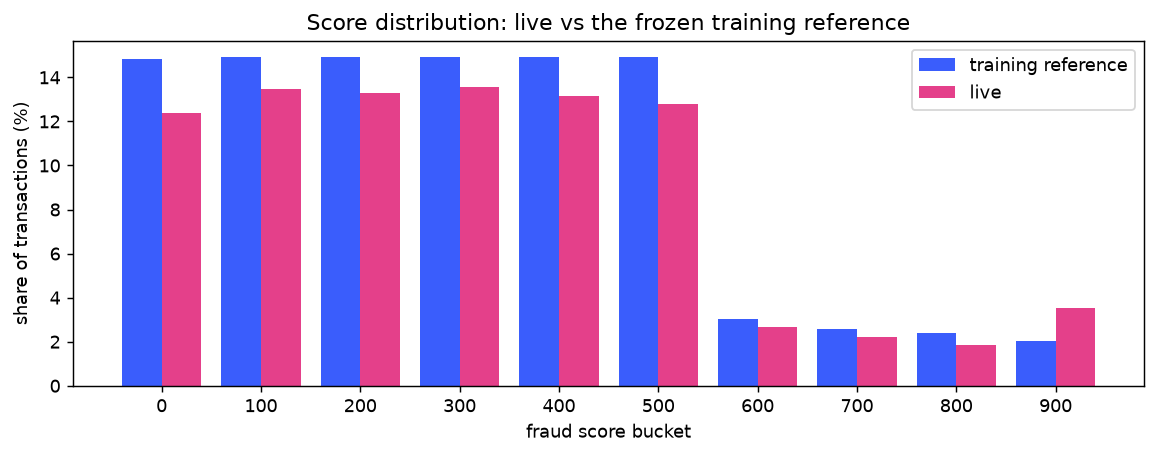

In [10]:
rng = np.random.default_rng(6)
# simulated fraud-campaign burst (clearly synthetic) so live diverges from training
burst = pd.concat([train, test])[lambda d: d["is_fraud"] == 1].sample(
    1500, replace=True, random_state=6
)
live = pd.concat([test, burst], ignore_index=True)
s_live = afd_score(model.predict_proba(live[features])[:, 1], legit_reference)

B = 100
ref = (
    pd.Series((s_train // B) * B)
    .value_counts(normalize=True)
    .reindex(range(0, 1000, B), fill_value=0)
)
liv = (
    pd.Series((s_live // B) * B)
    .value_counts(normalize=True)
    .reindex(range(0, 1000, B), fill_value=0)
)
x = np.arange(len(ref))
plt.figure(figsize=(9, 3.6), dpi=130)
plt.bar(x - 0.2, ref.values * 100, 0.4, label="training reference", color="#3A5DFC")
plt.bar(x + 0.2, liv.values * 100, 0.4, label="live", color="#E4408A")
plt.xticks(x, ref.index)
plt.xlabel("fraud score bucket")
plt.ylabel("share of transactions (%)")
plt.title("Score distribution: live vs the frozen training reference")
plt.legend()
plt.tight_layout()
plt.show()

The DBShap attribution itself. The exact Shapley over the nine features; the value of a coalition is the mean-score shift when its features come from the live marginal. The bars sum to the total mean-score drift.

In [11]:
from itertools import combinations
from math import factorial


def dbshap(model, features, train, live, legit, rng, N=2000):
    """Return the per-feature Shapley attribution of the mean-score drift (label-free)."""
    n = len(features)
    tr = np.column_stack([rng.choice(train[f].values, N) for f in features])
    lv = np.column_stack([rng.choice(live[f].values, N) for f in features])
    big = np.empty((2**n * N, n))
    for c in range(2**n):
        bits = np.array([(c >> j) & 1 for j in range(n)], bool)
        big[c * N : (c + 1) * N] = np.where(bits[None, :], lv, tr)
    v = (
        afd_score(model.predict_proba(pd.DataFrame(big, columns=features))[:, 1], legit)
        .reshape(2**n, N)
        .mean(1)
    )
    v = v - v[0]  # v(empty)=0
    w = {k: factorial(k) * factorial(n - k - 1) / factorial(n) for k in range(n)}
    phi = np.zeros(n)
    for j in range(n):
        others = [i for i in range(n) if i != j]
        for k in range(len(others) + 1):
            for sub in combinations(others, k):
                s = sum(1 << i for i in sub)
                phi[j] += w[k] * (v[s | (1 << j)] - v[s])
    return sorted(zip(features, phi), key=lambda t: t[1])


attrib = dbshap(model, features, train, live, legit_reference, rng)
print(
    f"total mean-score drift = {sum(p for _, p in attrib):.1f}  (= sum of contributions)"
)
attrib[::-1]

total mean-score drift = 77.5  (= sum of contributions)


[('merchant_fraud_rate', np.float64(57.72884305555554)),
 ('amount_over_user_avg', np.float64(9.727582341269855)),
 ('amount_usd', np.float64(3.5259448412698484)),
 ('merchant_age_days', np.float64(2.9799924603174595)),
 ('is_night', np.float64(1.4842382936507923)),
 ('is_online', np.float64(1.2537680555555584)),
 ('seconds_since_last_txn', np.float64(0.5289365079365128)),
 ('user_txn_count_24h', np.float64(0.4012728174603217)),
 ('is_first_merchant', np.float64(-0.08107837301587381))]

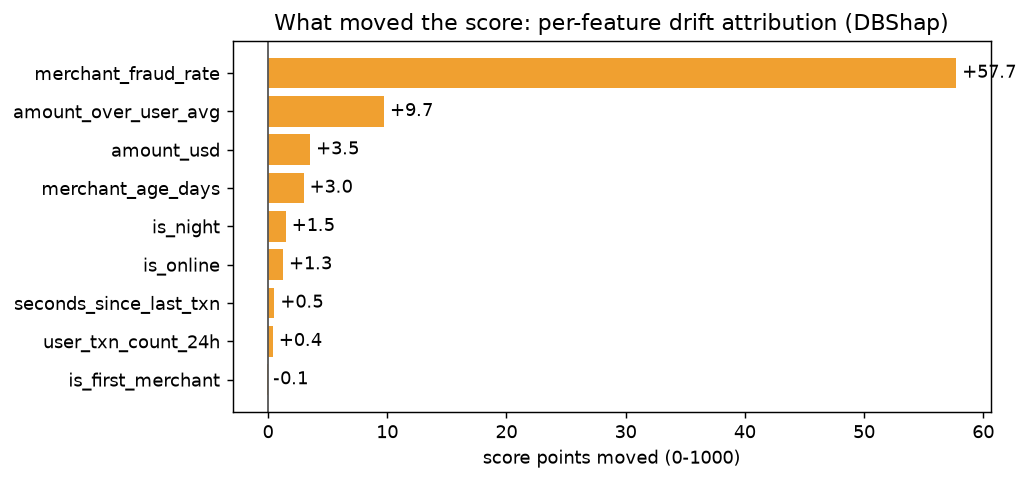

In [12]:
labels = [f for f, _ in attrib]
vals = [p for _, p in attrib]
plt.figure(figsize=(8, 3.8), dpi=130)
plt.barh(labels, vals, color="#F0A030")
for i, v in enumerate(vals):
    plt.text(v, i, f" {v:+.1f}", va="center")
plt.axvline(0, color="#555", lw=1)
plt.xlabel("score points moved (0-1000)")
plt.title("What moved the score: per-feature drift attribution (DBShap)")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-bar" style="color:#18ab4b"></i>&nbsp; On the live board</h2>

`src/scoring/monitoring.py` writes exactly these three results to the warehouse, `score_reference`, `score_monitor`, and `drift_attribution`, and the Grafana board renders them as the monitoring row: the daily live-score line, the live-versus-training distribution, and this attribution. Run it with `make monitor` while the local stack is up. The picture the fraud desk sees is the same one this notebook just built: the score rose, the distribution shifted, and one or two features carried the move.